<a href="https://colab.research.google.com/github/SaddamHosen42/Multi_class_and_Binary_heart_disease/blob/main/Multi_class_and_Binary_heart_disease_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Laibary**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ──────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve, auc)
# ── Imbalanced-learn ─────────────────────────────────────────
from imblearn.over_sampling import RandomOverSampler

# **STEP 1 – DATA LOADING**

In [ ]:
# Cleveland Heart Disease dataset (UCI processed version)
# 303 samples × 14 columns; '?' denotes missing values
url = ('https://raw.githubusercontent.com/SaddamHosen42/'
       'Heart-Disease-Prediction/refs/heads/main/processed.cleveland.data')

col_names = ['age','sex','cp','trestbps','chol','fbs',
             'restecg','thalach','exang','oldpeak','slope','ca','thal','target']

df = pd.read_csv(url, header=None, names=col_names, na_values='?')
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

Dataset shape: (303, 14)

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [ ]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,0,145.0,233.0,1,2,150.0,0,2.3,2,0,1,0
1,67.0,1,3,160.0,286.0,0,2,108.0,1,1.5,1,3,0,2
2,67.0,1,3,120.0,229.0,0,2,129.0,1,2.6,1,2,2,1
3,37.0,1,2,130.0,250.0,0,0,187.0,0,3.5,2,0,0,0
4,41.0,0,1,130.0,204.0,0,2,172.0,0,1.4,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1,0,110.0,264.0,0,0,132.0,0,1.2,1,0,2,1
299,68.0,1,3,144.0,193.0,1,0,141.0,0,3.4,1,2,2,2
300,57.0,1,3,130.0,131.0,0,0,115.0,1,1.2,1,1,2,3
301,57.0,0,1,130.0,236.0,0,2,174.0,0,0.0,1,1,0,1


# **STEP 2 – PREPROCESSING**

In [ ]:
# 2-a: Fill missing values with column mode (most frequent value)
#      Only 'ca' and 'thal' have missing entries in this dataset
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# 2-b: Label Encoding – convert categorical columns to integers
#      Required so all classifiers receive numeric input (paper §3.1.1)
le = LabelEncoder()
categorical_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# 2-c: Separate feature matrix from target vector
X = df.drop('target', axis=1).values          # shape: (303, 13)

# Binary target  – 0 = no disease, 1 = disease (original classes 1-4 → 1)
y_binary = (df['target'] > 0).astype(int).values

# Multi-class target – 0 = no disease, 1/2/3/4 = increasing severity
y_multi  = df['target'].values

print("\nBinary class distribution :")
unique, counts = np.unique(y_binary, return_counts=True)
print(dict(zip(unique, counts)))

print("\nMulti-class distribution   :")
unique, counts = np.unique(y_multi, return_counts=True)
print(dict(zip(unique, counts)))


Binary class distribution :
{np.int64(0): np.int64(164), np.int64(1): np.int64(139)}

Multi-class distribution   :
{np.int64(0): np.int64(164), np.int64(1): np.int64(55), np.int64(2): np.int64(36), np.int64(3): np.int64(35), np.int64(4): np.int64(13)}


# **STEP 3 – HELPER FUNCTIONS**

In [ ]:
def scale_fold(X_train_fold, X_val_fold, method='standard'):
    """
    Fit scaler ONLY on the training fold, then transform both folds.
    This is the correct way to prevent data leakage:
    the validation fold must NEVER influence the scaler's parameters.

    method='standard' → StandardScaler (z-score): used for LR / SVM / ANN
    method='minmax'   → MinMaxScaler  (0-1 range): used for DT / RF / ADA
    """
    scaler = StandardScaler() if method == 'standard' else MinMaxScaler()
    X_tr_sc  = scaler.fit_transform(X_train_fold)   # fit + transform
    X_val_sc = scaler.transform(X_val_fold)          # transform only
    return X_tr_sc, X_val_sc


def evaluate_fold(y_true, y_pred, y_prob=None, multi=False):
    """
    Compute five classification metrics for one CV fold:
      Accuracy  – fraction of correct predictions
      Precision – weighted/macro average across classes
      Recall    – sensitivity (true positive rate)
      F1-Score  – harmonic mean of precision & recall
      ROC-AUC   – area under ROC curve (None if not computable)

    multi=True  → weighted average (handles 5-class imbalance)
    multi=False → macro average (equal weight per class for binary)
    """
    avg = 'weighted' if multi else 'macro'
    acc = accuracy_score(y_true, y_pred) * 100
    prc = precision_score(y_true, y_pred, average=avg, zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average=avg, zero_division=0) * 100
    f1  = f1_score(y_true, y_pred, average=avg, zero_division=0) * 100
    roc = None
    if y_prob is not None:
        try:
            if multi:
                # One-vs-Rest AUC for multi-class
                roc = roc_auc_score(y_true, y_prob,
                                    multi_class='ovr',
                                    average='macro') * 100
            else:
                # Probability of positive class (column 1)
                roc = roc_auc_score(y_true, y_prob[:, 1]) * 100
        except Exception:
            roc = None    # e.g. a class absent in this fold's val set
    return acc, prc, rec, f1, roc


def print_fold_result(fold_idx, label, acc, prc, rec, f1, roc=None):
    """Print metrics for one fold in a compact, aligned format."""
    roc_str = f"  ROC-AUC={roc:.2f}%" if roc is not None else ""
    print(f"    Fold {fold_idx} [{label:<18}] "
          f"Acc={acc:.2f}%  Prec={prc:.2f}%  "
          f"Recall={rec:.2f}%  F1={f1:.2f}%{roc_str}")


def print_cv_summary(label, scores_dict):
    """
    Print mean ± std for every metric after all 5 folds complete.
    scores_dict keys: 'acc', 'prc', 'rec', 'f1', 'roc'
    """
    print(f"\n  ── CV Summary [{label}] ──────────────────────────────")
    for metric, vals in scores_dict.items():
        arr = [v for v in vals if v is not None]  # skip None ROC entries
        if arr:
            print(f"    {metric.upper():<8}: "
                  f"{np.mean(arr):.2f}% ± {np.std(arr):.2f}%")


def weighted_score_fusion(model1, model2, X_val, y_val,
                           w_range=None, multi=False):
    """
    Weighted Score Fusion – paper §3.1.3 & Algorithm 1.

    Equation (3):  fused_prob = W1 * prob1 + W2 * prob2
                   where W1 + W2 = 1

    Sweeps W1 from 0.95 down to 0.05 in steps of 0.05.
    Picks the weight pair that maximises accuracy on the validation fold.
    Returns: (best_predictions, best_fused_probs, best_W1)

    IMPORTANT: Both models MUST have been trained on the SAME
    training fold and evaluated on the SAME validation fold.
    """
    if w_range is None:
        # 19 pairs: (0.95,0.05), (0.90,0.10), ..., (0.05,0.95)
        w_range = [round(0.95 - 0.05*i, 2) for i in range(19)]

    prob1 = model1.predict_proba(X_val)   # (n_val, n_classes)
    prob2 = model2.predict_proba(X_val)

    best_acc, best_w1, best_fused = 0, None, None

    for w1 in w_range:
        w2     = round(1 - w1, 2)
        fused  = w1 * prob1 + w2 * prob2           # weighted combination
        y_pred = np.argmax(fused, axis=1)

        # For binary: argmax gives 0 or 1, map back to actual class labels
        if not multi:
            y_pred = model1.classes_[y_pred]

        acc = accuracy_score(y_val, y_pred) * 100
        if acc > best_acc:
            best_acc, best_w1, best_fused = acc, w1, fused

    # Final predictions with the best weight pair
    y_pred_best = np.argmax(best_fused, axis=1)
    if not multi:
        y_pred_best = model1.classes_[y_pred_best]

    return y_pred_best, best_fused, best_w1


# ── Which models use which scaler (paper §3.1.2) ──────────
STD_MODELS = {'LR', 'SVM', 'ANN'}   # gradient/distance-based → z-score
MM_MODELS  = {'DT', 'RF', 'ADA'}    # tree-based             → min-max

# **STEP 4 – HYPERPARAMETER GRIDS**

In [ ]:
# GridSearchCV will try every combination (Cartesian product).
# Tuning is done INSIDE the outer CV loop on the training fold ONLY.

PARAM_GRIDS_BINARY = {
    'LR':  {'C': [0.001, 0.01, 0.1, 1, 10],
             'max_iter': [1000], 'solver': ['lbfgs']},

    'SVM': {'C': [0.01, 0.1, 1, 10, 100],
             'gamma': ['scale', 0.01, 0.1, 1], 'kernel': ['rbf']},

    'DT':  {'criterion': ['gini', 'entropy'],
             'max_depth': [4, 6, 8, None],
             'min_samples_leaf': [1, 3, 5, 7],
             'splitter': ['best', 'random']},

    'RF':  {'n_estimators': [50, 100, 200],
             'max_depth': [None, 5, 10],
             'min_samples_leaf': [1, 2, 4]},

    'ANN': {'hidden_layer_sizes': [(8,), (16,), (8, 8)],
             'learning_rate_init': [0.001, 0.01],
             'alpha': [0.0001, 0.001],
             'max_iter': [200], 'solver': ['adam', 'sgd']},

    'ADA': {'n_estimators': [100, 200, 250],
             'learning_rate': [0.001, 0.01, 0.1, 1.0]},
}

PARAM_GRIDS_MULTI = {
    'LR':  {'C': [0.001, 0.01, 0.1, 1],
             'max_iter': [1000],
             'multi_class': ['multinomial'], 'solver': ['lbfgs']},

    'SVM': {'C': [0.01, 0.1, 1, 10, 100],
             'gamma': ['scale', 0.01, 0.1], 'kernel': ['rbf']},

    'RF':  {'n_estimators': [100, 200],
             'max_depth': [None, 5, 10],
             'min_samples_leaf': [1, 2]},

    'ANN': {'hidden_layer_sizes': [(8,), (16,), (8, 8)],
             'learning_rate_init': [0.001, 0.01],
             'alpha': [0.0001, 0.001],
             'max_iter': [200], 'solver': ['adam', 'sgd']},
}

# ── Base (un-tuned) model instances ───────────────────────
# GridSearchCV clones these; random_state ensures reproducibility
BASE_MODELS_BINARY = {
    'LR':  LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'DT':  DecisionTreeClassifier(random_state=42),
    'RF':  RandomForestClassifier(random_state=42),
    'ANN': MLPClassifier(batch_size=10, random_state=42),
    'ADA': AdaBoostClassifier(random_state=42),
}

BASE_MODELS_MULTI = {
    'LR':  LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'RF':  RandomForestClassifier(random_state=42),
    'ANN': MLPClassifier(batch_size=5, random_state=42),
}

# **STEP 5 – INNER GRIDSEARCH TUNER (runs inside each fold)**

In [ ]:
def tune_on_fold(name, base_model, param_grid,
                 X_train_fold, y_train_fold, inner_cv=5):
    """
    Run GridSearchCV with an INNER 5-Fold StratifiedKFold
    using ONLY the current outer fold's training data.

    This is a nested cross-validation approach:
      Outer fold  → produces train / val split
      Inner folds → used by GridSearchCV to find best hyperparameters

    refit=True  → best model is refit on the full outer training fold
    n_jobs=-1   → use all CPU cores for speed
    """
    inner_skf = StratifiedKFold(n_splits=inner_cv,
                                shuffle=True, random_state=42)
    grid = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=inner_skf,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0,
        refit=True             # refit best model on full training fold
    )
    grid.fit(X_train_fold, y_train_fold)
    return grid.best_estimator_, grid.best_params_

# **STEP 6 – VISUALIZATION HELPERS**

In [ ]:
def plot_confusion_matrix(y_true_all, y_pred_all, labels, title):
    """
    Plot a confusion matrix aggregated over ALL folds.
    Concatenating all fold predictions gives a full-dataset picture
    without any single fold dominating the result.
    """
    cm   = confusion_matrix(y_true_all, y_pred_all)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'cm_{title.replace(" ","_")}.png', dpi=120)
    plt.show()


def plot_roc_curve_binary(fpr_list, tpr_list, auc_list, title):
    """
    Overlay ROC curves from all 5 folds and draw the mean curve.
    Shaded band shows ± std of TPR at each FPR point.
    """
    plt.figure(figsize=(7, 5))
    mean_fpr = np.linspace(0, 1, 100)
    tprs_interp = []

    for fold_idx, (fpr, tpr, auc_val) in enumerate(
            zip(fpr_list, tpr_list, auc_list), 1):
        plt.plot(fpr, tpr, alpha=0.3, lw=1,
                 label=f'Fold {fold_idx} (AUC={auc_val:.2f})')
        # Interpolate TPR at common FPR grid for mean curve
        tprs_interp.append(np.interp(mean_fpr, fpr, tpr))

    mean_tpr = np.mean(tprs_interp, axis=0)
    std_tpr  = np.std(tprs_interp, axis=0)
    mean_auc = np.mean(auc_list)

    plt.plot(mean_fpr, mean_tpr, 'b-', lw=2,
             label=f'Mean ROC (AUC={mean_auc:.2f})')
    plt.fill_between(mean_fpr,
                     mean_tpr - std_tpr,
                     mean_tpr + std_tpr,
                     alpha=0.15, color='blue', label='± 1 std')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right', fontsize=7)
    plt.tight_layout()
    plt.savefig(f'roc_{title.replace(" ","_")}.png', dpi=120)
    plt.show()


def plot_metric_bars(summary_dict, title):
    """
    Grouped bar chart: mean metric values across all models / fusion pairs.
    Error bars show ± std across the 5 folds.
    """
    labels  = list(summary_dict.keys())
    metrics = ['acc', 'prc', 'rec', 'f1']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
    x, width = np.arange(len(labels)), 0.2

    fig, ax = plt.subplots(figsize=(13, 5))
    for i, (m, ml) in enumerate(zip(metrics, metric_labels)):
        means  = [np.mean(summary_dict[l][m]) for l in labels]
        stds   = [np.std(summary_dict[l][m])  for l in labels]
        ax.bar(x + i*width, means, width, yerr=stds,
               capsize=4, label=ml)

    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylabel('Score (%)')
    ax.set_title(title)
    ax.set_ylim(0, 115)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'bar_{title.replace(" ","_")}.png', dpi=120)
    plt.show()


# **STEP 7 – BINARY CLASSIFICATION  (5-Fold Outer CV)**


  BINARY CLASSIFICATION – 5-Fold Stratified CV + GridSearch

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FOLD 1 / 5
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train samples: 242  |  Val samples: 61

  Tuning models on fold 1 training data...
    Fold 1 [LR                ] Acc=91.80%  Prec=91.70%  Recall=91.88%  F1=91.77%  ROC-AUC=93.72%
          Best params: {'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}
    Fold 1 [SVM               ] Acc=93.44%  Prec=93.40%  Recall=93.40%  F1=93.40%  ROC-AUC=94.26%
          Best params: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
    Fold 1 [DT                ] Acc=90.16%  Prec=90.10%  Recall=90.10%  F1=90.10%  ROC-AUC=93.02%
          Best params: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 7, 'splitter': 'random'}
    Fold 1 [RF                ] Acc=88.52%  Prec=88.56%  Recall=88.31%  F1=88.41%  ROC-AUC=95.13%
          Best params: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 20

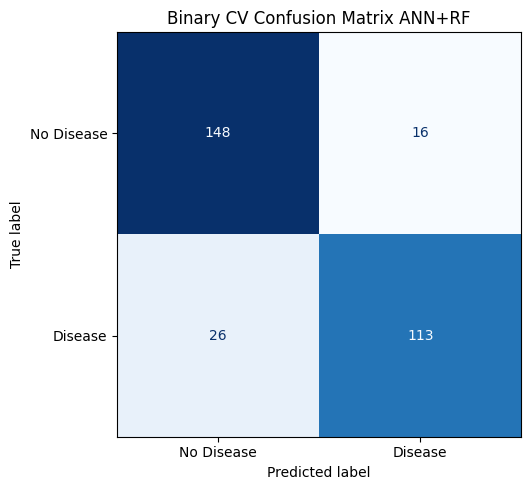

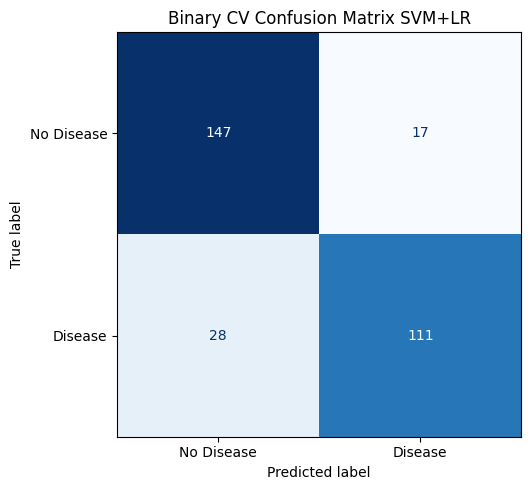

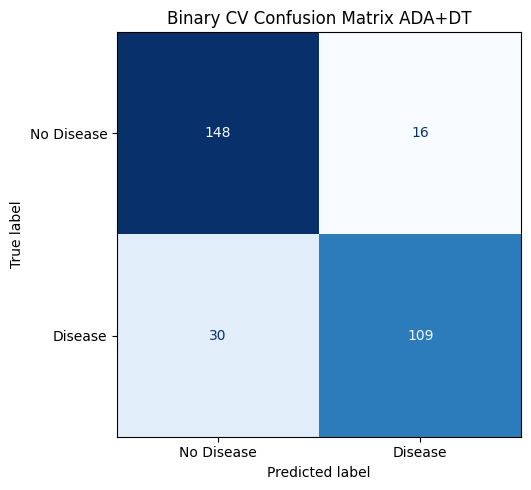

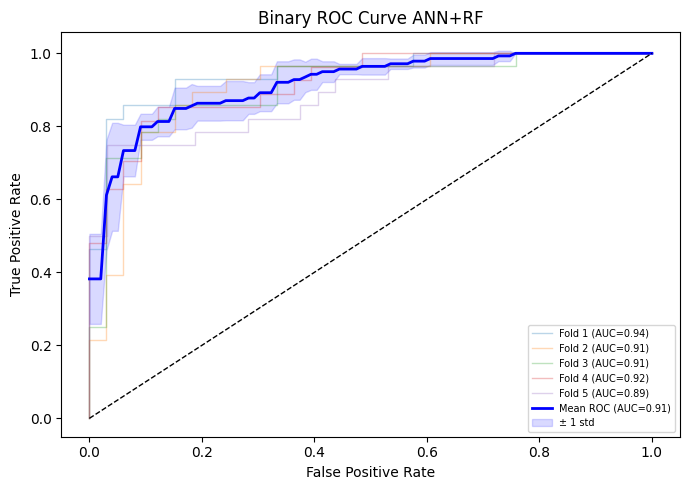

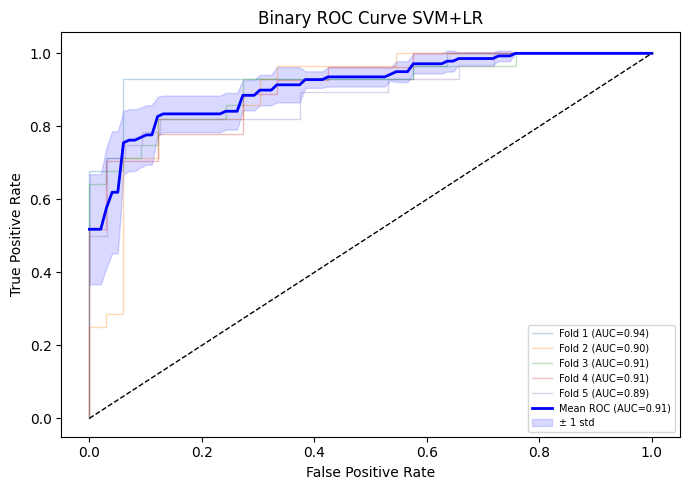

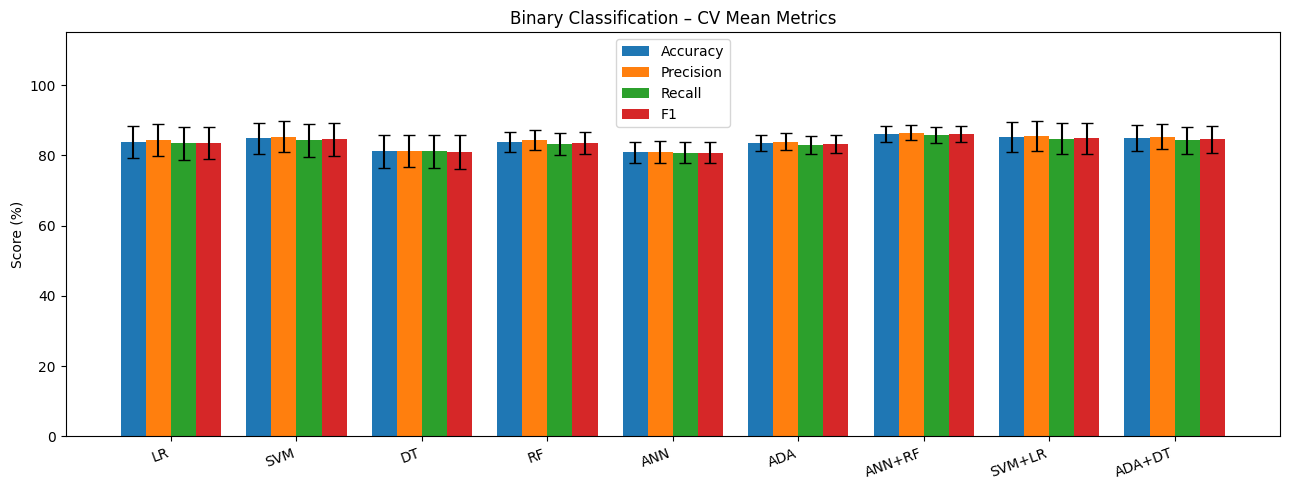

In [ ]:
print("\n" + "="*65)
print("  BINARY CLASSIFICATION – 5-Fold Stratified CV + GridSearch")
print("="*65)

# Outer CV splitter – stratified so each fold preserves class ratio
outer_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Containers for per-fold scores ────────────────────────
# Individual models
binary_indiv_scores = {
    name: {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]}
    for name in BASE_MODELS_BINARY
}

# Fusion pairs
binary_fusion_scores = {
    'ANN+RF':  {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
    'SVM+LR':  {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
    'ADA+DT':  {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
}

# Aggregated predictions across all folds (for confusion matrix & ROC)
binary_agg = {key: {'y_true':[], 'y_pred':[]}
              for key in list(BASE_MODELS_BINARY.keys()) +
                         list(binary_fusion_scores.keys())}

# ROC curve data per fold (binary classifiers)
roc_fold_data = {key: {'fpr':[], 'tpr':[], 'auc':[]}
                 for key in ['ANN', 'RF', 'SVM', 'LR', 'ANN+RF', 'SVM+LR']}

# ── Outer CV loop ─────────────────────────────────────────
for fold_idx, (train_idx, val_idx) in enumerate(
        outer_skf.split(X, y_binary), 1):

    print(f"\n  {'━'*58}")
    print(f"  FOLD {fold_idx} / 5")
    print(f"  {'━'*58}")
    print(f"  Train samples: {len(train_idx)}  |  Val samples: {len(val_idx)}")

    # ── Raw fold splits (unscaled) ────────────────────────
    X_tr_raw, X_val_raw = X[train_idx], X[val_idx]
    y_tr,     y_val     = y_binary[train_idx], y_binary[val_idx]

    # ── Scale inside the fold – NO leakage from val set ──
    # StandardScaler for gradient/distance-based models
    X_tr_std, X_val_std = scale_fold(X_tr_raw, X_val_raw, 'standard')
    # MinMaxScaler for tree-based models
    X_tr_mm,  X_val_mm  = scale_fold(X_tr_raw, X_val_raw, 'minmax')

    # Mapping: model name → (train_scaled, val_scaled)
    scale_map = {
        'LR':  (X_tr_std, X_val_std),
        'SVM': (X_tr_std, X_val_std),
        'ANN': (X_tr_std, X_val_std),
        'DT':  (X_tr_mm,  X_val_mm),
        'RF':  (X_tr_mm,  X_val_mm),
        'ADA': (X_tr_mm,  X_val_mm),
    }

    # ── Tune & train each individual model ───────────────
    # GridSearchCV uses an INNER 5-fold CV on X_tr_* only
    trained = {}
    print(f"\n  Tuning models on fold {fold_idx} training data...")

    for name, base in BASE_MODELS_BINARY.items():
        Xtr_, Xval_ = scale_map[name]

        # Inner GridSearch (nested CV) to find best hyperparameters
        best_model, best_params = tune_on_fold(
            name, base, PARAM_GRIDS_BINARY[name], Xtr_, y_tr)

        trained[name] = (best_model, Xval_)

        # Evaluate tuned model on the OUTER validation fold
        y_pred = best_model.predict(Xval_)
        y_prob = best_model.predict_proba(Xval_)
        acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred, y_prob, multi=False)

        # Store fold scores
        binary_indiv_scores[name]['acc'].append(acc)
        binary_indiv_scores[name]['prc'].append(prc)
        binary_indiv_scores[name]['rec'].append(rec)
        binary_indiv_scores[name]['f1'].append(f1)
        binary_indiv_scores[name]['roc'].append(roc)

        # Aggregate predictions for confusion matrix
        binary_agg[name]['y_true'].extend(y_val)
        binary_agg[name]['y_pred'].extend(y_pred)

        # Store ROC curve data for LR, SVM, ANN, RF
        if name in roc_fold_data:
            fpr_, tpr_, _ = roc_curve(y_val, y_prob[:, 1])
            roc_fold_data[name]['fpr'].append(fpr_)
            roc_fold_data[name]['tpr'].append(tpr_)
            roc_fold_data[name]['auc'].append(
                auc(fpr_, tpr_) if roc is None else roc / 100)

        print_fold_result(fold_idx, name, acc, prc, rec, f1, roc)
        print(f"          Best params: {best_params}")

    # ── Fusion Model-1: ANN + RF ──────────────────────────
    # Both models are evaluated on X_val_std (ANN's scaler)
    # RF was trained on X_tr_mm but predict_proba can accept any array;
    # here we pass X_val_std consistently as in the paper's fusion approach
    print(f"\n  Fusion results for fold {fold_idx}:")
    ann_m, _ = trained['ANN']
    rf_m,  _ = trained['RF']

    y_pred_f1, prob_f1, w1 = weighted_score_fusion(
        ann_m, rf_m, X_val_std, y_val, multi=False)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred_f1, None, multi=False)
    binary_fusion_scores['ANN+RF']['acc'].append(acc)
    binary_fusion_scores['ANN+RF']['prc'].append(prc)
    binary_fusion_scores['ANN+RF']['rec'].append(rec)
    binary_fusion_scores['ANN+RF']['f1'].append(f1)
    binary_fusion_scores['ANN+RF']['roc'].append(roc)
    binary_agg['ANN+RF']['y_true'].extend(y_val)
    binary_agg['ANN+RF']['y_pred'].extend(y_pred_f1)
    print_fold_result(fold_idx, f"ANN+RF (w1={w1})", acc, prc, rec, f1, roc)

    # Store ROC for ANN+RF fusion
    try:
        fpr_, tpr_, _ = roc_curve(y_val, prob_f1[:, 1])
        roc_fold_data['ANN+RF']['fpr'].append(fpr_)
        roc_fold_data['ANN+RF']['tpr'].append(tpr_)
        roc_fold_data['ANN+RF']['auc'].append(auc(fpr_, tpr_))
    except Exception:
        pass

    # ── Fusion Model-2: SVM + LR ──────────────────────────
    svm_m, _ = trained['SVM']
    lr_m,  _ = trained['LR']
    y_pred_f2, prob_f2, w2 = weighted_score_fusion(
        svm_m, lr_m, X_val_std, y_val, multi=False)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred_f2, None, multi=False)
    binary_fusion_scores['SVM+LR']['acc'].append(acc)
    binary_fusion_scores['SVM+LR']['prc'].append(prc)
    binary_fusion_scores['SVM+LR']['rec'].append(rec)
    binary_fusion_scores['SVM+LR']['f1'].append(f1)
    binary_fusion_scores['SVM+LR']['roc'].append(roc)
    binary_agg['SVM+LR']['y_true'].extend(y_val)
    binary_agg['SVM+LR']['y_pred'].extend(y_pred_f2)
    print_fold_result(fold_idx, f"SVM+LR (w1={w2})", acc, prc, rec, f1, roc)

    # Store ROC for SVM+LR fusion
    try:
        fpr_, tpr_, _ = roc_curve(y_val, prob_f2[:, 1])
        roc_fold_data['SVM+LR']['fpr'].append(fpr_)
        roc_fold_data['SVM+LR']['tpr'].append(tpr_)
        roc_fold_data['SVM+LR']['auc'].append(auc(fpr_, tpr_))
    except Exception:
        pass

    # ── Fusion Model-3: ADA + DT ──────────────────────────
    ada_m, _ = trained['ADA']
    dt_m,  _ = trained['DT']
    y_pred_f3, prob_f3, w3 = weighted_score_fusion(
        ada_m, dt_m, X_val_mm, y_val, multi=False)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred_f3, None, multi=False)
    binary_fusion_scores['ADA+DT']['acc'].append(acc)
    binary_fusion_scores['ADA+DT']['prc'].append(prc)
    binary_fusion_scores['ADA+DT']['rec'].append(rec)
    binary_fusion_scores['ADA+DT']['f1'].append(f1)
    binary_fusion_scores['ADA+DT']['roc'].append(roc)
    binary_agg['ADA+DT']['y_true'].extend(y_val)
    binary_agg['ADA+DT']['y_pred'].extend(y_pred_f3)
    print_fold_result(fold_idx, f"ADA+DT (w1={w3})", acc, prc, rec, f1, roc)

# ── Cross-validation Summaries ────────────────────────────
print("\n" + "="*65)
print("  BINARY CV SUMMARIES (Mean ± Std across 5 folds)")
print("="*65)

print("\n  Individual Models:")
for name, scores in binary_indiv_scores.items():
    print_cv_summary(name, scores)

print("\n  Fusion Models:")
for name, scores in binary_fusion_scores.items():
    print_cv_summary(name, scores)

# ── Confusion matrices (aggregated across all folds) ──────
for key in ['ANN+RF', 'SVM+LR', 'ADA+DT']:
    plot_confusion_matrix(
        binary_agg[key]['y_true'],
        binary_agg[key]['y_pred'],
        labels=['No Disease', 'Disease'],
        title=f'Binary CV Confusion Matrix {key}')

# ── ROC curves ────────────────────────────────────────────
for key in ['ANN+RF', 'SVM+LR']:
    if roc_fold_data[key]['fpr']:
        plot_roc_curve_binary(
            roc_fold_data[key]['fpr'],
            roc_fold_data[key]['tpr'],
            roc_fold_data[key]['auc'],
            title=f'Binary ROC Curve {key}')

# ── Bar chart comparing all binary models ─────────────────
all_binary_summary = {**binary_indiv_scores, **binary_fusion_scores}
plot_metric_bars(all_binary_summary,
                 'Binary Classification – CV Mean Metrics')


# **STEP 8 – MULTI-CLASS CLASSIFICATION  (5-Fold CV)**


  MULTI-CLASS CLASSIFICATION – 5-Fold Stratified CV + GridSearch


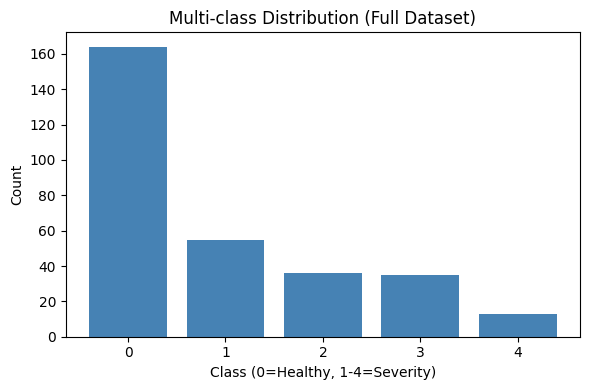


  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  FOLD 1 / 5
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train: 242 samples  |  Val: 61 samples
  After oversampling – train size: 655
  Class counts in train fold: {np.int64(0): np.int64(131), np.int64(1): np.int64(131), np.int64(2): np.int64(131), np.int64(3): np.int64(131), np.int64(4): np.int64(131)}

  Tuning multi-class models on fold 1...
    Fold 1 [LR                ] Acc=57.38%  Prec=61.24%  Recall=57.38%  F1=58.72%  ROC-AUC=79.57%
          Best params: {'C': 0.01, 'max_iter': 1000, 'multi_class': 'multinomial', 'solver': 'lbfgs'}
    Fold 1 [SVM               ] Acc=60.66%  Prec=57.17%  Recall=60.66%  F1=58.79%  ROC-AUC=78.88%
          Best params: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
    Fold 1 [RF                ] Acc=60.66%  Prec=55.30%  Recall=60.66%  F1=57.65%  ROC-AUC=74.37%
          Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
    Fold 1 [ANN        

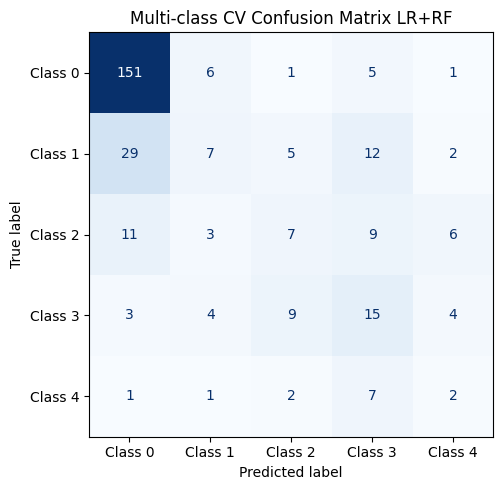

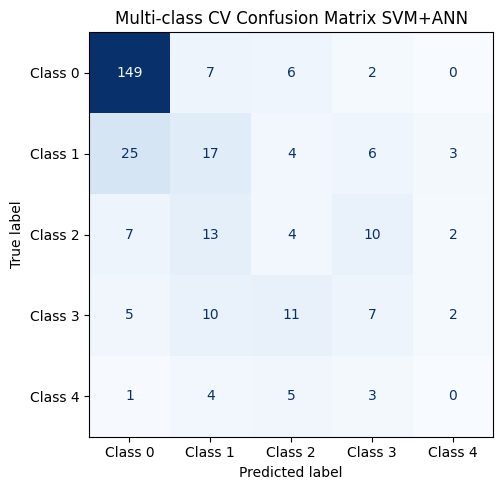

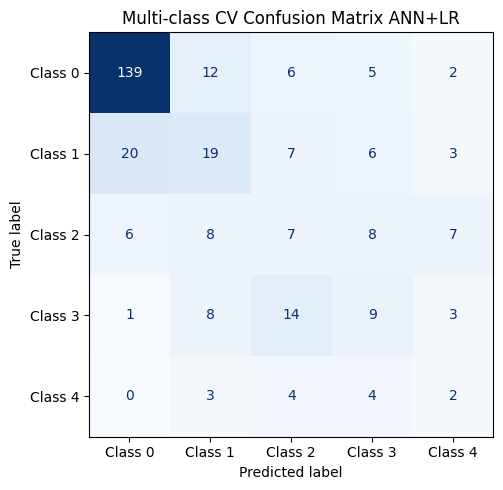

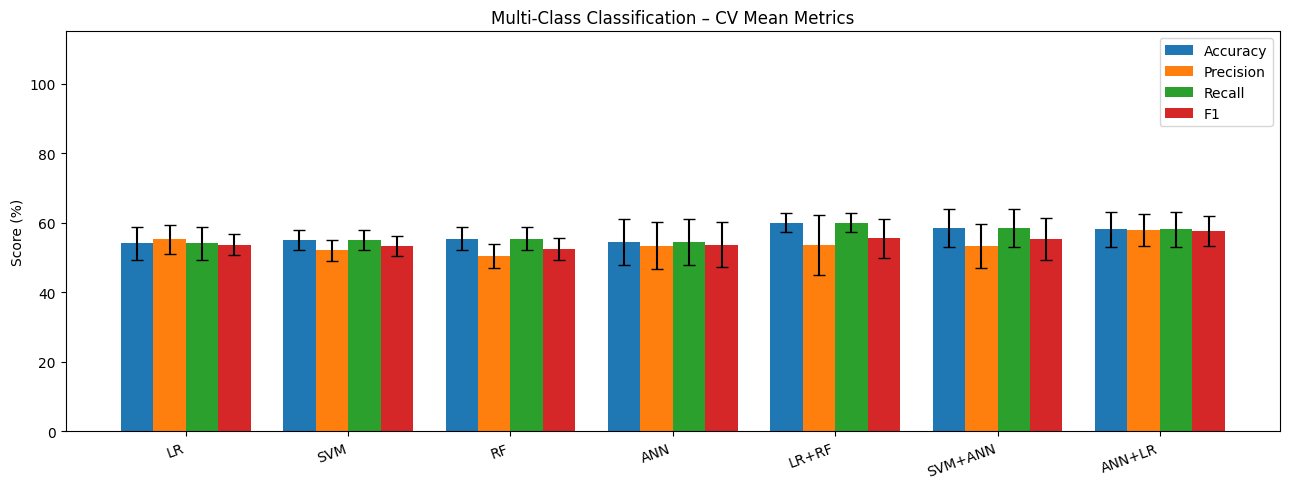


✅ All 5-Fold CV experiments complete!
   Saved: multiclass_distribution.png
          cm_*.png  |  roc_*.png  |  bar_*.png


In [ ]:
print("\n" + "="*65)
print("  MULTI-CLASS CLASSIFICATION – 5-Fold Stratified CV + GridSearch")
print("="*65)

# Show class distribution BEFORE oversampling
plt.figure(figsize=(6, 4))
unique, counts = np.unique(y_multi, return_counts=True)
plt.bar([str(u) for u in unique], counts, color='steelblue')
plt.title('Multi-class Distribution (Full Dataset)')
plt.xlabel('Class (0=Healthy, 1-4=Severity)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('multiclass_distribution.png', dpi=120)
plt.show()

# ── Containers ────────────────────────────────────────────
multi_indiv_scores = {
    name: {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]}
    for name in BASE_MODELS_MULTI
}

multi_fusion_scores = {
    'LR+RF':   {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
    'SVM+ANN': {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
    'ANN+LR':  {'acc':[], 'prc':[], 'rec':[], 'f1':[], 'roc':[]},
}

multi_agg = {key: {'y_true':[], 'y_pred':[]}
             for key in list(BASE_MODELS_MULTI.keys()) +
                        list(multi_fusion_scores.keys())}

# ── Outer CV loop ─────────────────────────────────────────
outer_skf_multi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_idx, val_idx) in enumerate(
        outer_skf_multi.split(X, y_multi), 1):

    print(f"\n  {'━'*58}")
    print(f"  FOLD {fold_idx} / 5")
    print(f"  {'━'*58}")
    print(f"  Train: {len(train_idx)} samples  |  Val: {len(val_idx)} samples")

    X_tr_raw, X_val_raw = X[train_idx], X[val_idx]
    y_tr,     y_val     = y_multi[train_idx], y_multi[val_idx]

    # ── RandomOverSampler – ONLY on training fold ─────────
    # Duplicates minority-class samples until all classes are equal.
    # NEVER applied to the validation fold (would cause leakage).
    ros = RandomOverSampler(random_state=42)
    X_tr_res, y_tr_res = ros.fit_resample(X_tr_raw, y_tr)

    print(f"  After oversampling – train size: {len(X_tr_res)}")
    unique_res, counts_res = np.unique(y_tr_res, return_counts=True)
    print(f"  Class counts in train fold: {dict(zip(unique_res, counts_res))}")

    # ── Scale AFTER oversampling, BEFORE training ─────────
    # Scaler fitted on oversampled training data; val fold untouched
    X_tr_std, X_val_std = scale_fold(X_tr_res, X_val_raw, 'standard')
    X_tr_mm,  X_val_mm  = scale_fold(X_tr_res, X_val_raw, 'minmax')

    scale_map_m = {
        'LR':  (X_tr_std, X_val_std),
        'SVM': (X_tr_std, X_val_std),
        'RF':  (X_tr_mm,  X_val_mm),
        'ANN': (X_tr_std, X_val_std),
    }

    # ── Tune & train each individual model ───────────────
    trained_m = {}
    print(f"\n  Tuning multi-class models on fold {fold_idx}...")

    for name, base in BASE_MODELS_MULTI.items():
        Xtr_, Xval_ = scale_map_m[name]

        # Inner GridSearch on oversampled training fold only
        best_model, best_params = tune_on_fold(
            name, base, PARAM_GRIDS_MULTI[name], Xtr_, y_tr_res)

        trained_m[name] = (best_model, Xval_)

        y_pred = best_model.predict(Xval_)
        y_prob = best_model.predict_proba(Xval_)
        acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred, y_prob, multi=True)

        multi_indiv_scores[name]['acc'].append(acc)
        multi_indiv_scores[name]['prc'].append(prc)
        multi_indiv_scores[name]['rec'].append(rec)
        multi_indiv_scores[name]['f1'].append(f1)
        multi_indiv_scores[name]['roc'].append(roc)

        multi_agg[name]['y_true'].extend(y_val)
        multi_agg[name]['y_pred'].extend(y_pred)

        print_fold_result(fold_idx, name, acc, prc, rec, f1, roc)
        print(f"          Best params: {best_params}")

    # ── Fusion Model-1: LR + RF ───────────────────────────
    print(f"\n  Multi-class fusion results for fold {fold_idx}:")
    lr_m,  _ = trained_m['LR']
    rf_m,  _ = trained_m['RF']
    y_pred_f1, prob_f1, w1 = weighted_score_fusion(
        lr_m, rf_m, X_val_std, y_val, multi=True)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred_f1, prob_f1, multi=True)
    multi_fusion_scores['LR+RF']['acc'].append(acc)
    multi_fusion_scores['LR+RF']['prc'].append(prc)
    multi_fusion_scores['LR+RF']['rec'].append(rec)
    multi_fusion_scores['LR+RF']['f1'].append(f1)
    multi_fusion_scores['LR+RF']['roc'].append(roc)
    multi_agg['LR+RF']['y_true'].extend(y_val)
    multi_agg['LR+RF']['y_pred'].extend(y_pred_f1)
    print_fold_result(fold_idx, f"LR+RF (w1={w1})", acc, prc, rec, f1, roc)

    # ── Fusion Model-2: SVM + ANN ─────────────────────────
    svm_m, _ = trained_m['SVM']
    ann_m, _ = trained_m['ANN']
    y_pred_f2, prob_f2, w2 = weighted_score_fusion(
        svm_m, ann_m, X_val_std, y_val, multi=True)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred_f2, prob_f2, multi=True)
    multi_fusion_scores['SVM+ANN']['acc'].append(acc)
    multi_fusion_scores['SVM+ANN']['prc'].append(prc)
    multi_fusion_scores['SVM+ANN']['rec'].append(rec)
    multi_fusion_scores['SVM+ANN']['f1'].append(f1)
    multi_fusion_scores['SVM+ANN']['roc'].append(roc)
    multi_agg['SVM+ANN']['y_true'].extend(y_val)
    multi_agg['SVM+ANN']['y_pred'].extend(y_pred_f2)
    print_fold_result(fold_idx, f"SVM+ANN (w1={w2})", acc, prc, rec, f1, roc)

    # ── Fusion Model-3: ANN + LR ──────────────────────────
    y_pred_f3, prob_f3, w3 = weighted_score_fusion(
        ann_m, lr_m, X_val_std, y_val, multi=True)
    acc, prc, rec, f1, roc = evaluate_fold(y_val, y_pred_f3, prob_f3, multi=True)
    multi_fusion_scores['ANN+LR']['acc'].append(acc)
    multi_fusion_scores['ANN+LR']['prc'].append(prc)
    multi_fusion_scores['ANN+LR']['rec'].append(rec)
    multi_fusion_scores['ANN+LR']['f1'].append(f1)
    multi_fusion_scores['ANN+LR']['roc'].append(roc)
    multi_agg['ANN+LR']['y_true'].extend(y_val)
    multi_agg['ANN+LR']['y_pred'].extend(y_pred_f3)
    print_fold_result(fold_idx, f"ANN+LR (w1={w3})", acc, prc, rec, f1, roc)

# ── Cross-validation Summaries ────────────────────────────
print("\n" + "="*65)
print("  MULTI-CLASS CV SUMMARIES (Mean ± Std across 5 folds)")
print("="*65)

print("\n  Individual Models:")
for name, scores in multi_indiv_scores.items():
    print_cv_summary(name, scores)

print("\n  Fusion Models:")
for name, scores in multi_fusion_scores.items():
    print_cv_summary(name, scores)

# ── Confusion matrices (aggregated across all folds) ──────
class_labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
for key in ['LR+RF', 'SVM+ANN', 'ANN+LR']:
    plot_confusion_matrix(
        multi_agg[key]['y_true'],
        multi_agg[key]['y_pred'],
        labels=class_labels,
        title=f'Multi-class CV Confusion Matrix {key}')

# ── Bar chart comparing all multi-class models ────────────
all_multi_summary = {**multi_indiv_scores, **multi_fusion_scores}
plot_metric_bars(all_multi_summary,
                 'Multi-Class Classification – CV Mean Metrics')


# ╔══════════════════════════════════════════════════════════╗
# ║  DONE                                                   ║
# ╚══════════════════════════════════════════════════════════╝
print("\n✅ All 5-Fold CV experiments complete!")
print("   Saved: multiclass_distribution.png")
print("          cm_*.png  |  roc_*.png  |  bar_*.png")